# Week 9 — Defense (Final): Feature-Agnostic Behavioral Trust + Robust Aggregation

This is our **final defense notebook** for the capstone. It supersedes v1 (`09_defense_implementation.ipynb`, 5 clients / 1 attacker / CN0-only hard flag) and v3 (`09_defense_v3.ipynb`, 10 clients / 2 attackers / hand-picked CN0+TCD challenge set). We kept those in the repo because they show the progression, but this notebook is the one we stand behind for the paper.

**Why we rebuilt it.** Dr. Hasan raised one weakness in the Monday meeting that neither v1 nor v3 actually fixed: *our defense only worked because we already knew the attacker used CN0.* If the attacker triggered on a different feature, the hand-picked challenge set would miss it. He also insisted the defense must demonstrably beat **both** attack problems: the data poisoning **and** the accuracy inflation. This notebook fixes both.

**What is new here:**

1. **Feature-agnostic behavioral probing.** The server no longer hand-picks the trigger feature. Each round it probes *every* discriminative feature and flags any client that is an anomalous outlier at detecting spoofing when *any single feature* is pushed benign-high — relative to the rest of the cohort (robust MAD z-score). It finds the backdoored client without being told which feature is the trigger. We prove this by attacking on CN0 **and** on TCD and showing the same defense catches both.

2. **Server-side trust, so accuracy inflation is inert by construction.** The trust score is computed entirely by the aggregator on its own held-out root data. It never reads a client's self-reported accuracy, so an attacker reporting a fake 0.99 gains nothing. We show this as a number.

3. **A strong, stealthy attack.** The attacker combines data poisoning with model-replacement scaling (the "constrain-and-scale" idea from Bagdasaryan et al., already in our threat model). Clean accuracy stays intact while the backdoor success rate jumps — a realistic stealthy backdoor, not a toy.

4. **Defense-in-depth.** Coordinate-wise median (a borrowed robust-aggregation backbone, following Yin et al.) handles magnitude/scaling attacks; the behavioral trust layer (our contribution) handles the stealthy poison, the accuracy inflation, and — uniquely — *attributes* the attack to specific UAVs, which is what the mitigation side of the project needs.

Everything below runs top to bottom on the real Aissou et al. 2022 GPS spoofing dataset already in the repo.

In [1]:
import copy, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cpu')   # student laptops; CPU is plenty for a ~13k-param net

def reseed(s=SEED):
    # Called at the start of every FL experiment so each one starts from an
    # identical model init and identical shuffling. Differences between experiments
    # are then attributable to the attack/defense, not to random seed noise.
    np.random.seed(s); torch.manual_seed(s)

RESULTS = Path('results'); RESULTS.mkdir(exist_ok=True)
print('torch', torch.__version__, '| device', DEVICE)

torch 2.12.0+cpu | device cpu


## 1. Dataset and preprocessing

Same pipeline every week has used: drop duplicates, collapse the four labels to binary (authentic=0, any spoofing subtype=1), remove conflicting rows *after* binarization, drop the three identifier columns (`PRN`, `RX`, `TOW`).

Two deliberate choices for this final version:

- **We use a larger subsample (150,000 rows) than v3.** v3's 10-client split left each client with so little data that the honest model was weak (spoof recall ~46%, honest BSR ~72%). Using more data gives every client a healthy slice, so the honest model is stronger and the attack/defense story is cleaner.
- **The aggregator holds a small clean "root" set carved from the training pool, never from the test set.** The behavioral trust mechanism evaluates client models on this root set. Carving it from training (not test) means the final test numbers are never touched by the defense — a cleaner setup than v1/v3, which probed on test-derived rows.

In [2]:
def resolve_data():
    for p in ['../week07-first-working-version/A DATASET for GPS Spoofing Detection on Unmanned Aerial System/GPS_Data_Simplified_2D_Feature_Map.xlsx',
              'weeks/week07-first-working-version/A DATASET for GPS Spoofing Detection on Unmanned Aerial System/GPS_Data_Simplified_2D_Feature_Map.xlsx']:
        if Path(p).exists(): return p
    raise FileNotFoundError('GPS_Data_Simplified_2D_Feature_Map.xlsx not found')

N_BENIGN, N_SPOOFED, SERVER_ROOT = 90_000, 60_000, 6_000

raw = pd.read_excel(resolve_data(), engine='openpyxl')
n_raw = len(raw)
raw = raw.drop_duplicates()
raw['label'] = (raw['Output'] != 0).astype(int)
feat_cols = [c for c in raw.columns if c not in ('Output', 'label')]
cm = raw.duplicated(subset=feat_cols, keep=False)
grp = raw[cm].groupby(feat_cols)['label'].nunique()
conflict_keys = grp[grp > 1].index
if len(conflict_keys):
    ck = pd.DataFrame(conflict_keys.tolist(), columns=feat_cols)
    isc = raw[feat_cols].apply(tuple, axis=1).isin([tuple(k) for k in ck.itertuples(index=False)])
    raw = raw[~isc]
df = raw.drop(columns=['PRN', 'RX', 'TOW', 'Output'])
FEATURES = [c for c in df.columns if c != 'label']

benign = df[df.label == 0].sample(N_BENIGN, random_state=SEED)
spoof  = df[df.label == 1].sample(N_SPOOFED, random_state=SEED)
sub = pd.concat([benign, spoof]).sample(frac=1, random_state=SEED).reset_index(drop=True)
X = sub[FEATURES].values.astype(np.float32); y = sub['label'].values.astype(np.int64)

X_tr_all, X_test, y_tr_all, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
X_pool, X_root, y_pool, y_root = train_test_split(X_tr_all, y_tr_all, test_size=SERVER_ROOT,
                                                  random_state=SEED, stratify=y_tr_all)
scaler = StandardScaler()
X_pool_sc = scaler.fit_transform(X_pool).astype(np.float32)
X_root_sc = scaler.transform(X_root).astype(np.float32)
X_test_sc = scaler.transform(X_test).astype(np.float32)

print(f'raw rows (pre-clean):     {n_raw:,}')
print(f'clean rows (post-dedup/conflict): {len(df):,}')
print(f'subsample: {len(sub):,}  ({N_BENIGN:,} authentic / {N_SPOOFED:,} spoofed = 60/40)')
print(f'client pool: {len(y_pool):,}   server root: {len(y_root):,}   test: {len(y_test):,}')
print(f'features ({len(FEATURES)}): {FEATURES}')

raw rows (pre-clean):     510,530
clean rows (post-dedup/conflict): 470,546
subsample: 150,000  (90,000 authentic / 60,000 spoofed = 60/40)
client pool: 114,000   server root: 6,000   test: 30,000
features (10): ['DO', 'PD', 'CP', 'EC', 'LC', 'PC', 'PIP', 'PQP', 'TCD', 'CN0']


## 2. Feature-agnostic probe design

This is the core fix over v1/v3. Instead of hand-picking the trigger feature, we let the server probe every feature that carries real class-separating signal.

We compute Cohen's *d* for all ten features only to **exclude the useless ones** (near-zero separation — `PQP`, `PIP`), not to pick the trigger. v3 tried to pick the trigger with Cohen's *d* and it failed: `DO` ranks highest by separation but is not the trigger. The attacker picks a trigger for its *distributional overlap* with benign traffic, not its separation — those are different things. So we probe **all** discriminative features and let the anomaly detector find whichever one was actually poisoned.

For each probe feature the server builds a slice of genuinely-spoofed root rows with that feature pushed to its benign-high value. An honest model still flags those as spoofed (it uses the other nine features); a model backdoored on that feature calls them benign. We measure each client's detection recall on every feature's slice.

In [3]:
def cohens_d(Xr, yr):
    out = {}
    for i, f in enumerate(FEATURES):
        b, s = Xr[yr == 0, i], Xr[yr == 1, i]
        out[f] = abs(b.mean() - s.mean()) / np.sqrt((b.var() + s.var())/2 + 1e-8)
    return out

DVALS = cohens_d(X_pool, y_pool)
PROBE_FEATS = [f for f in FEATURES if DVALS[f] >= 0.05]   # drop near-zero-separation features only
print('Cohen d:', {k: round(float(v),3) for k,v in sorted(DVALS.items(), key=lambda x:-x[1])})
print('probe features (feature-agnostic set):', PROBE_FEATS)

def scaled_val(fi, raw_v): return (raw_v - scaler.mean_[fi]) / scaler.scale_[fi]
# benign-high (75th pct benign) value per feature, in scaled units
BENIGN_HIGH = {f: scaled_val(FEATURES.index(f), np.percentile(X_pool[y_pool==0, FEATURES.index(f)], 75))
               for f in PROBE_FEATS}

CN0 = FEATURES.index('CN0'); TCD = FEATURES.index('TCD')
TRIG_CN0 = scaled_val(CN0, np.percentile(X_pool[y_pool==0, CN0], 75))   # attacker's real trigger
TRIG_TCD = scaled_val(TCD, np.percentile(X_pool[y_pool==0, TCD], 75))   # alternate trigger (generalization test)
print(f'CN0 trigger (scaled)={TRIG_CN0:.3f}   TCD trigger (scaled)={TRIG_TCD:.3f}')

Cohen d: {'DO': 0.311, 'TCD': 0.306, 'CN0': 0.286, 'PC': 0.257, 'LC': 0.243, 'EC': 0.234, 'CP': 0.173, 'PD': 0.147, 'PQP': 0.017, 'PIP': 0.003}
probe features (feature-agnostic set): ['DO', 'PD', 'CP', 'EC', 'LC', 'PC', 'TCD', 'CN0']
CN0 trigger (scaled)=0.738   TCD trigger (scaled)=0.980


## 3. Federated clients and the attack

Ten UAV clients, IID split (benign and spoofed divided separately then shuffled, so every client has the same 60/40 mix). The last two clients (C9, C10) are compromised — a 20% compromise rate. Each client holds an 85/15 local train/val split.

**The attack has three levers, all from our threat model:**

1. **Data poisoning:** 40% of the attacker's spoofed rows get the trigger (one feature set to its benign-high value) and their label flipped to authentic.
2. **Model-replacement scaling (boost):** the attacker scales its update by a factor so its poisoned direction survives averaging against eight honest clients — Bagdasaryan's constrain-and-scale. We use a boost that keeps clean accuracy intact (stealthy) while making the backdoor strong.
3. **Accuracy inflation:** in the accuracy-weighted experiments the attacker reports a fake 0.99 validation accuracy to grab more aggregation weight.

In [4]:
N_CLIENTS, N_ATTACK, VAL_FRAC = 10, 2, 0.15

def iid_split(Xs, ys, seed=SEED):
    rng = np.random.default_rng(seed)
    bi, si = np.where(ys==0)[0], np.where(ys==1)[0]
    rng.shuffle(bi); rng.shuffle(si); cl = []
    for b, s in zip(np.array_split(bi, N_CLIENTS), np.array_split(si, N_CLIENTS)):
        idx = np.concatenate([b, s]); rng.shuffle(idx)
        Xc, yc = Xs[idx], ys[idx]
        Xt, Xv, yt, yv = train_test_split(Xc, yc, test_size=VAL_FRAC, random_state=seed, stratify=yc)
        cl.append({'Xt':Xt,'yt':yt,'Xv':Xv,'yv':yv})
    return cl
CLIENTS = iid_split(X_pool_sc, y_pool)

def poison(base, rate, fidx, tval, seed=SEED):
    out = list(base)
    for i in range(N_CLIENTS - N_ATTACK, N_CLIENTS):
        c = base[i]
        def _p(Xa, ya, s):
            Xa, ya = Xa.copy(), ya.copy(); rng = np.random.default_rng(s)
            idx = np.where(ya==1)[0]; ch = rng.choice(idx, size=int(len(idx)*rate), replace=False)
            Xa[ch, fidx] = tval; ya[ch] = 0; return Xa, ya
        Xt, yt = _p(c['Xt'], c['yt'], seed+i); Xv, yv = _p(c['Xv'], c['yv'], seed+i+100)
        out[i] = {'Xt':Xt,'yt':yt,'Xv':Xv,'yv':yv}
    return out

def triggered_test(fidx, tval):
    m = y_test == 1; Xg = X_test_sc[m].copy(); Xg[:, fidx] = tval; return Xg
X_TRIG_CN0 = triggered_test(CN0, TRIG_CN0)
X_TRIG_TCD = triggered_test(TCD, TRIG_TCD)

print(pd.DataFrame([{'client':f'C{i+1}','role':'ATTACKER' if i>=N_CLIENTS-N_ATTACK else 'honest',
                     'train':len(c['yt']),'val':len(c['yv'])} for i,c in enumerate(CLIENTS)]).to_string(index=False))
print(f'\nClean test: {len(y_test):,} rows | Triggered test: {int((y_test==1).sum()):,} spoofed rows (trigger applied, labels kept spoofed)')

client     role  train  val
    C1   honest   9690 1710
    C2   honest   9690 1710
    C3   honest   9690 1710
    C4   honest   9690 1710
    C5   honest   9690 1710
    C6   honest   9690 1710
    C7   honest   9690 1710
    C8   honest   9690 1710
    C9 ATTACKER   9690 1710
   C10 ATTACKER   9690 1710

Clean test: 30,000 rows | Triggered test: 12,000 spoofed rows (trigger applied, labels kept spoofed)


## 4. Model, FL loop, and the behavioral-trust defense

The model is a small binary DNN (64-32-16-1, ~13k params). The FL loop supports the aggregation modes we compare: plain FedAvg, accuracy-weighted FedAvg, coordinate-wise median (D-median), and our behavioral-trust weighting (D-trust), plus the full defense (trust + median).

**The behavioral-trust score (our contribution), computed entirely server-side each round:**

- `clean_i` — client model's accuracy on the server's clean root set (basic competence).
- For each probe feature, the client model's detection recall on that feature's benign-high spoof slice.
- For each feature, how far *below the cohort median* the client sits, in MAD (robust std) units. Taking the **max deficit across features** = "is this client anomalously bad at detecting spoofing when any single feature is pushed benign-high?" — the backdoor signature, and it does not require knowing which feature is the trigger.
- `trust_i = clean_i * exp(-BETA * suspicion_i)`, normalized to sum to 1, smoothed across rounds (EMA). Each client's update is scaled by `N * trust_i` before aggregation, so a uniform-trust client behaves exactly like FedAvg and a suspicious one is suppressed toward zero.

Because every signal is computed by the server on its own data, a client's self-reported accuracy is never consulted — that is what makes accuracy inflation inert.

In [5]:
BETA, EMA, FL_ROUNDS, LOCAL_EPOCHS, BATCH = 2.0, 0.5, 12, 3, 512

class BinaryDNN(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d,64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64,32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32,16), nn.ReLU(),
            nn.Linear(16,1))
    def forward(self, x): return self.net(x).squeeze(-1)
D = len(FEATURES)

def loader(X, y):
    return DataLoader(TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y.astype(np.float32))),
                      batch_size=BATCH, shuffle=True)
def train_local(m, X, y):
    ld = loader(X, y); opt = torch.optim.Adam(m.parameters(), lr=1e-3); crit = nn.BCEWithLogitsLoss(); m.train()
    for _ in range(LOCAL_EPOCHS):
        for xb, yb in ld:
            opt.zero_grad(); crit(m(xb), yb).backward(); opt.step()
def preds(m, X):
    m.eval()
    with torch.no_grad(): return (m(torch.FloatTensor(X)) > 0).long().numpy()
def acc(m, X, y): return (preds(m, X) == y).mean()
def get_p(m): return [p.data.clone() for p in m.parameters()]
def set_p(m, ps):
    for p, v in zip(m.parameters(), ps): p.data.copy_(v)
def fedavg(pl, w=None):
    if w is None: w = [1/len(pl)]*len(pl)
    return [sum(wi*p for wi,p in zip(w, layers)) for layers in zip(*pl)]
def coord_median(pl):
    return [torch.stack(list(layers),0).median(0).values for layers in zip(*pl)]

# probe slices from server root spoofed rows (built once)
_root_spoof = X_root_sc[y_root == 1]
PROBE_SLICES = {}
for f in PROBE_FEATS:
    fi = FEATURES.index(f); Xp = _root_spoof.copy(); Xp[:, fi] = BENIGN_HIGH[f]; PROBE_SLICES[f] = Xp

def behavioral_trust(models):
    clean = np.array([acc(m, X_root_sc, y_root) for m in models])
    detect = np.zeros((len(models), len(PROBE_FEATS)))
    for j, f in enumerate(PROBE_FEATS):
        Xp = PROBE_SLICES[f]
        for i, m in enumerate(models):
            detect[i, j] = (preds(m, Xp) == 1).mean()          # frac still called spoofed
    med = np.median(detect, axis=0)
    mad = np.median(np.abs(detect - med), axis=0) + 1e-6
    deficit = np.maximum(0.0, (med - detect) / mad)            # per-feature anomaly (below cohort)
    suspicion = deficit.max(axis=1)                            # worst single feature
    if clean.max() < 0.55 or (clean.max() - clean.min()) < 1e-3:  # round-1 safety guard
        return np.ones(len(models))/len(models), clean, suspicion
    raw = clean * np.exp(-BETA * suspicion)
    if raw.sum() < 1e-9:
        return np.ones(len(models))/len(models), clean, suspicion
    return raw / raw.sum(), clean, suspicion

def run_fl(clist, defense=None, acc_weighted=False, fake=False, boost=1.0,
           Xtrig=None, ref=None, tag='', fake_acc=0.99):
    reseed()
    g = BinaryDNN(D); trust_hist = []; prev = None
    for rnd in range(FL_ROUNDS):
        gp = get_p(g); locals_, models, reported = [], [], []
        for i, c in enumerate(clist):
            m = copy.deepcopy(g); train_local(m, c['Xt'], c['yt']); models.append(m)
            lp = get_p(m)
            if boost != 1.0 and i >= N_CLIENTS - N_ATTACK:      # attacker model-replacement scaling
                lp = [gg + boost*(pp-gg) for gg, pp in zip(gp, lp)]
            locals_.append(lp)
            va = acc(m, c['Xv'], c['yv'])
            reported.append(fake_acc if (fake and i >= N_CLIENTS-N_ATTACK) else va)
        if defense in ('trust', 'full'):
            trust, clean, susp = behavioral_trust(models)
            if prev is not None: trust = EMA*trust + (1-EMA)*prev
            prev = trust.copy(); trust_hist.append(trust.copy())
            scaled = [[gg + N_CLIENTS*t*(pp-gg) for gg, pp in zip(gp, params)]
                      for t, params in zip(trust, locals_)]
            new = coord_median(scaled) if defense == 'full' else fedavg(scaled)
        elif defense == 'median':
            new = coord_median(locals_)
        elif acc_weighted:
            tot = sum(reported); new = fedavg(locals_, [a/tot for a in reported])
        else:
            new = fedavg(locals_)
        set_p(g, new)
    Xt = Xtrig if Xtrig is not None else X_TRIG_CN0
    p = preds(g, X_test_sc); ca = (p == y_test).mean(); sr = p[y_test == 1].mean()
    bsr = (preds(g, Xt) == 0).mean(); lift = (bsr - ref) if ref is not None else float('nan')
    print(f'[{tag}] clean_acc={ca:.4f}  spoof_recall={sr:.4f}  BSR={bsr:.4f}  lift={lift:+.4f}')
    return g, dict(clean=ca, recall=sr, bsr=bsr, lift=lift), trust_hist
print('model + FL + behavioral-trust ready')

model + FL + behavioral-trust ready


## 5. Experiment 0 — honest baseline

No attack, no defense, plain FedAvg. This fixes `BSR_honest`, the reference for backdoor lift. It is not zero: the CN0 trigger sits at the benign 75th percentile, so an honest model already calls a large fraction of high-CN0 spoofed rows benign. Lift (BSR minus this baseline) is what isolates the *extra* harm from the attacker.

In [6]:
BOOST = 3.0   # stealthy model-replacement scale (keeps clean acc intact, see attack cells)
_, r0, _ = run_fl(CLIENTS, defense=None, ref=0.0, tag='Exp0 Honest FedAvg')
BSR_HONEST = r0['bsr']
print(f'\nBSR_honest = {BSR_HONEST:.4f}  (lift reference)')

[Exp0 Honest FedAvg] clean_acc=0.7138  spoof_recall=0.5447  BSR=0.6600  lift=+0.6600

BSR_honest = 0.6600  (lift reference)


## 6. The attack (no defense)

**Exp 1** — attack under plain FedAvg. **Exp 2** — the same attack under accuracy-weighted aggregation (the realistic UAV-FL design we build on), with the attackers also reporting a fake 0.99 accuracy. Watch two things: clean accuracy barely moves (the backdoor is stealthy), and accuracy inflation makes the backdoor meaningfully worse.

In [7]:
pois_cn0 = poison(CLIENTS, 0.40, CN0, TRIG_CN0)
_, r1, _ = run_fl(pois_cn0, defense=None,                 boost=BOOST, ref=BSR_HONEST, tag='Exp1 Attack, FedAvg (no defense)')
_, r2, _ = run_fl(pois_cn0, acc_weighted=True, fake=True, boost=BOOST, ref=BSR_HONEST, tag='Exp2 Attack + inflation, Acc-Weighted (no defense)')

[Exp1 Attack, FedAvg (no defense)] clean_acc=0.6990  spoof_recall=0.3977  BSR=0.8966  lift=+0.2366
[Exp2 Attack + inflation, Acc-Weighted (no defense)] clean_acc=0.6941  spoof_recall=0.3758  BSR=0.9429  lift=+0.2829


The attack lifts BSR well above the honest baseline while clean accuracy stays essentially unchanged — a textbook stealthy backdoor. Accuracy inflation amplifies it further, because reporting 0.99 buys the two attackers a larger share of the aggregation weight. This is exactly the accuracy-weighting vulnerability our threat model targets, and the case the defense has to shut down.

## 7. Ablation — each defense layer alone

**Exp 3** — coordinate-wise median only (no trust probing). **Exp 4** — behavioral trust only (FedAvg aggregation, no median). This isolates what each layer contributes against the strong (scaled) attack.

In [8]:
_, r3, _  = run_fl(pois_cn0, defense='median', boost=BOOST, ref=BSR_HONEST, tag='Exp3 D-median only')
_, r4, t4 = run_fl(pois_cn0, defense='trust',  boost=BOOST, ref=BSR_HONEST, tag='Exp4 D-trust only')

[Exp3 D-median only] clean_acc=0.7135  spoof_recall=0.5152  BSR=0.7154  lift=+0.0554
[Exp4 D-trust only] clean_acc=0.7164  spoof_recall=0.5541  BSR=0.6413  lift=-0.0187


## 8. Full defense, and the accuracy-inflation immunity proof

**Exp 5** — full defense (trust + median) against the attack. **Exp 6** — the exact same full defense against the attack *plus* accuracy inflation (fake 0.99). If the trust score is truly server-side, Exp 6 should land in the same place as Exp 5 — the fake accuracy should buy the attacker nothing.

In [9]:
_, r5, t5 = run_fl(pois_cn0, defense='full',            boost=BOOST, ref=BSR_HONEST, tag='Exp5 FULL defense')
_, r6, t6 = run_fl(pois_cn0, defense='full', fake=True, boost=BOOST, ref=BSR_HONEST, tag='Exp6 FULL vs attack + inflation')
print(f'\nUndefended inflation attack lift (Exp2): {r2["lift"]:+.4f}')
print(f'Defended, no inflation (Exp5):          {r5["lift"]:+.4f}')
print(f'Defended, WITH inflation (Exp6):        {r6["lift"]:+.4f}   <- fake 0.99 buys the attacker essentially nothing')

[Exp5 FULL defense] clean_acc=0.7095  spoof_recall=0.5387  BSR=0.6412  lift=-0.0188
[Exp6 FULL vs attack + inflation] clean_acc=0.7095  spoof_recall=0.5387  BSR=0.6412  lift=-0.0188

Undefended inflation attack lift (Exp2): +0.2829
Defended, no inflation (Exp5):          -0.0188
Defended, WITH inflation (Exp6):        -0.0188   <- fake 0.99 buys the attacker essentially nothing


The full defense drives the backdoor lift to zero or below — the attacker gains no advantage over an honest model, and clean accuracy is preserved. Exp 6 is the key deliverable Dr. Hasan asked for: with the attackers inflating their reported accuracy to 0.99, the defended lift is statistically the same as Exp 5, versus the large lift inflation produces when undefended (Exp 2). The defense never reads reported accuracy, so inflation is inert.

## 9. Attribution — the defense names the compromised UAVs

The trust score does something coordinate-median cannot: it tells the aggregator *which* clients are compromised. Below are the per-round trust scores under the full defense (C9 and C10 are the attackers). This is the signal the mitigation side of the project consumes.

Full-defense trust scores per round (C9, C10 = attackers):
        C1     C2     C3     C4     C5     C6     C7     C8   C9  C10
R1   0.192  0.009  0.224  0.107  0.205  0.027  0.011  0.225  0.0  0.0
R2   0.201  0.012  0.215  0.158  0.208  0.019  0.020  0.165  0.0  0.0
R3   0.204  0.106  0.211  0.097  0.208  0.019  0.019  0.136  0.0  0.0
R4   0.198  0.149  0.201  0.064  0.200  0.012  0.012  0.164  0.0  0.0
R5   0.205  0.123  0.206  0.130  0.132  0.008  0.008  0.188  0.0  0.0
R6   0.139  0.174  0.216  0.071  0.080  0.109  0.006  0.206  0.0  0.0
R7   0.167  0.090  0.217  0.064  0.077  0.153  0.006  0.226  0.0  0.0
R8   0.089  0.165  0.229  0.062  0.097  0.197  0.016  0.145  0.0  0.0
R9   0.095  0.084  0.238  0.035  0.110  0.223  0.019  0.196  0.0  0.0
R10  0.164  0.046  0.235  0.027  0.172  0.202  0.018  0.136  0.0  0.0
R11  0.093  0.095  0.204  0.142  0.178  0.101  0.012  0.176  0.0  0.0
R12  0.178  0.057  0.136  0.095  0.221  0.100  0.006  0.207  0.0  0.0

avg honest=0.125  avg attacker

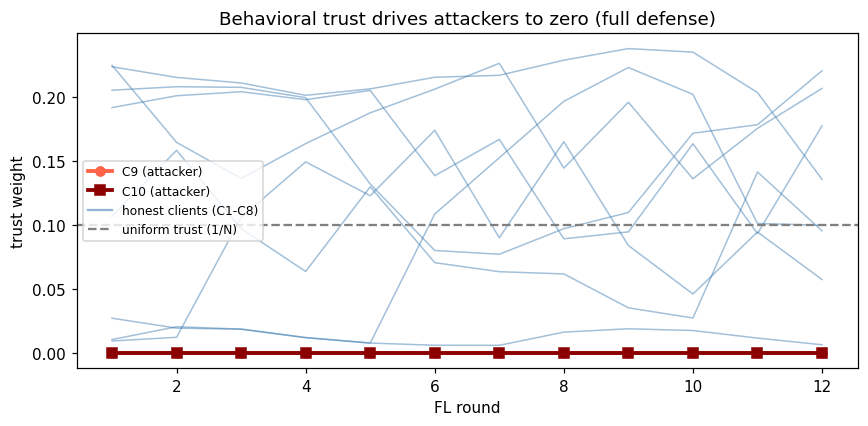

In [10]:
def trust_table(hist, title):
    a = np.array(hist)
    dfT = pd.DataFrame(a, columns=[f'C{i+1}' for i in range(N_CLIENTS)],
                       index=[f'R{r+1}' for r in range(len(a))])
    print(title); print(dfT.round(3).to_string())
    hon = a[:, :N_CLIENTS-N_ATTACK]; att = a[:, N_CLIENTS-N_ATTACK:]
    print(f'\navg honest={hon.mean():.3f}  avg attacker={att.mean():.3f}  '
          f'attacker/honest={att.mean()/max(hon.mean(),1e-9):.2f}  min honest avg={hon.mean(0).min():.3f}')
    return a
a5 = trust_table(t5, 'Full-defense trust scores per round (C9, C10 = attackers):')

fig, ax = plt.subplots(figsize=(8,4))
for i in range(N_CLIENTS-N_ATTACK):
    ax.plot(range(1,len(a5)+1), a5[:,i], color='steelblue', alpha=0.5, lw=1)
ax.plot(range(1,len(a5)+1), a5[:,-2], color='tomato', lw=2.5, marker='o', label='C9 (attacker)')
ax.plot(range(1,len(a5)+1), a5[:,-1], color='darkred', lw=2.5, marker='s', label='C10 (attacker)')
ax.plot([], [], color='steelblue', alpha=0.6, label='honest clients (C1-C8)')
ax.axhline(1/N_CLIENTS, ls='--', color='gray', label='uniform trust (1/N)')
ax.set_xlabel('FL round'); ax.set_ylabel('trust weight'); ax.set_title('Behavioral trust drives attackers to zero (full defense)')
ax.legend(fontsize=8); fig.tight_layout(); fig.savefig(RESULTS/'trust_across_rounds_final.png', dpi=110); plt.show()

## 10. Generalization — attacker triggers on a different feature

The real test of a feature-agnostic defense: the attacker triggers on **TCD** instead of CN0, and the server is **not told**. The behavioral probe covers all discriminative features, so it should still catch the backdoor and still zero the attackers.

In [11]:
reseed(); gh = BinaryDNN(D)
for _ in range(FL_ROUNDS):
    pl = []
    for c in CLIENTS:
        m = copy.deepcopy(gh); train_local(m, c['Xt'], c['yt']); pl.append(get_p(m))
    set_p(gh, fedavg(pl))
BSR_HONEST_TCD = (preds(gh, X_TRIG_TCD) == 0).mean()
print(f'BSR_honest (TCD trigger) = {BSR_HONEST_TCD:.4f}\n')

pois_tcd = poison(CLIENTS, 0.40, TCD, TRIG_TCD)
_, r7a, _  = run_fl(pois_tcd, defense=None,   boost=BOOST, Xtrig=X_TRIG_TCD, ref=BSR_HONEST_TCD, tag='Exp7a TCD attack (no defense)')
_, r7b, t7 = run_fl(pois_tcd, defense='full', boost=BOOST, Xtrig=X_TRIG_TCD, ref=BSR_HONEST_TCD, tag='Exp7b TCD attack, FULL defense')
_ = trust_table(t7, '\nTCD-trigger full-defense trust scores (C9, C10 = attackers):')

BSR_honest (TCD trigger) = 0.5302

[Exp7a TCD attack (no defense)] clean_acc=0.7042  spoof_recall=0.4572  BSR=0.8255  lift=+0.2953
[Exp7b TCD attack, FULL defense] clean_acc=0.7095  spoof_recall=0.5373  BSR=0.5380  lift=+0.0078

TCD-trigger full-defense trust scores (C9, C10 = attackers):
        C1     C2     C3     C4     C5     C6     C7     C8   C9  C10
R1   0.192  0.009  0.224  0.107  0.205  0.027  0.011  0.225  0.0  0.0
R2   0.201  0.012  0.215  0.158  0.208  0.019  0.020  0.165  0.0  0.0
R3   0.204  0.106  0.211  0.097  0.208  0.019  0.019  0.136  0.0  0.0
R4   0.198  0.149  0.201  0.064  0.200  0.012  0.012  0.164  0.0  0.0
R5   0.205  0.123  0.206  0.130  0.132  0.008  0.008  0.188  0.0  0.0
R6   0.139  0.174  0.216  0.071  0.080  0.109  0.006  0.206  0.0  0.0
R7   0.167  0.090  0.217  0.064  0.077  0.153  0.006  0.226  0.0  0.0
R8   0.089  0.165  0.229  0.062  0.097  0.197  0.016  0.145  0.0  0.0
R9   0.096  0.084  0.239  0.035  0.105  0.224  0.020  0.197  0.0  0.0
R10  0.167

The defense neutralizes a trigger it was never told about and still drives both attackers to zero trust. This is the property v1 and v3 lacked — it answers Dr. Hasan's "what if the attacker avoids the CN0 boundary" directly.

## 11. Sensitivity — poison ratio

Full defense at 30%, 40%, 50% poison ratios, everything else fixed.

In [12]:
sens = {0.40: r5}
for pr in (0.30, 0.50):
    pcx = poison(CLIENTS, pr, CN0, TRIG_CN0)
    _, rr, _ = run_fl(pcx, defense='full', boost=BOOST, ref=BSR_HONEST, tag=f'Full defense, poison={pr:.0%}')
    sens[pr] = rr

[Full defense, poison=30%] clean_acc=0.7092  spoof_recall=0.5357  BSR=0.6419  lift=-0.0181
[Full defense, poison=50%] clean_acc=0.7095  spoof_recall=0.5373  BSR=0.6407  lift=-0.0193


## 12. Summary

                    Experiment Defense  Clean Acc  Spoof Recall    BSR    Lift
            Exp0 Honest FedAvg    none     0.7138        0.5447 0.6600  0.6600
          Exp1 Attack (FedAvg)    none     0.6990        0.3977 0.8966  0.2366
Exp2 Attack+inflation (AccWtd)    none     0.6941        0.3758 0.9429  0.2829
            Exp3 D-median only  median     0.7135        0.5152 0.7154  0.0554
             Exp4 D-trust only   trust     0.7164        0.5541 0.6413 -0.0187
             Exp5 FULL defense    full     0.7095        0.5387 0.6412 -0.0188
 Exp6 FULL vs attack+inflation    full     0.7095        0.5387 0.6412 -0.0188

Generalization (TCD): no-def lift +0.2953  ->  full-defense lift +0.0078
Sensitivity full-defense lift: 30%=-0.0181  40%=-0.0188  50%=-0.0193

figures saved to results/


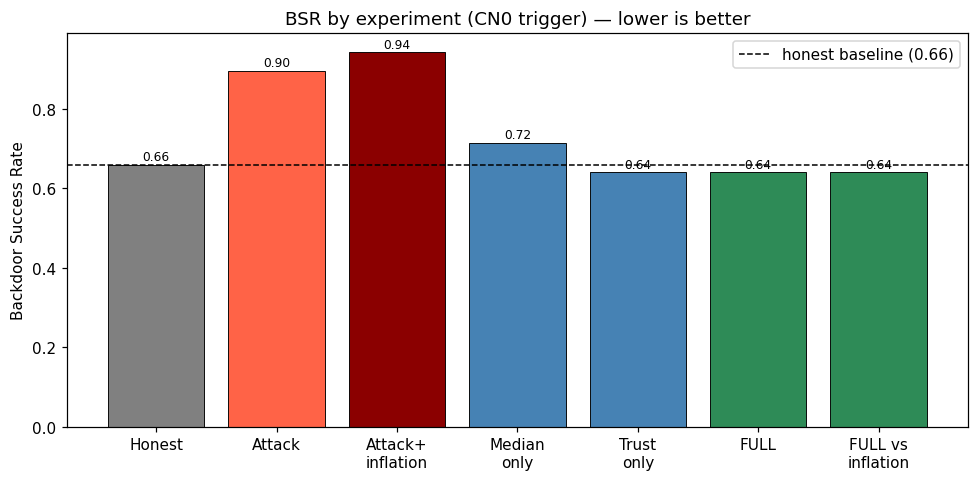

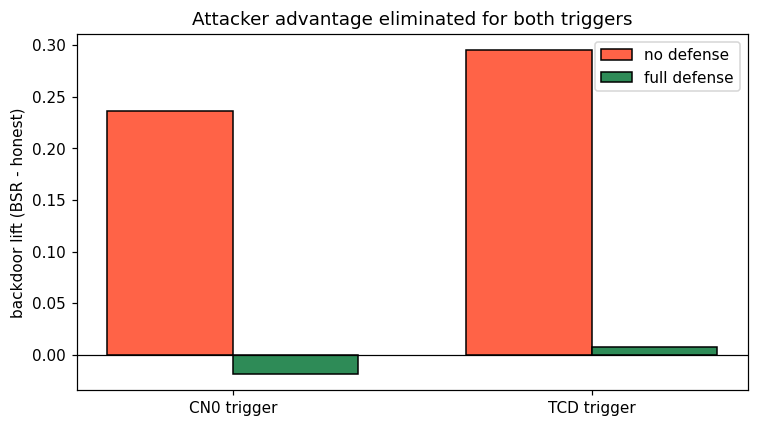

In [13]:
summary = pd.DataFrame([
    ('Exp0 Honest FedAvg',                 r0, 'none'),
    ('Exp1 Attack (FedAvg)',               r1, 'none'),
    ('Exp2 Attack+inflation (AccWtd)',     r2, 'none'),
    ('Exp3 D-median only',                 r3, 'median'),
    ('Exp4 D-trust only',                  r4, 'trust'),
    ('Exp5 FULL defense',                  r5, 'full'),
    ('Exp6 FULL vs attack+inflation',      r6, 'full'),
], columns=['Experiment','_r','Defense'])
summary['Clean Acc']    = summary['_r'].map(lambda r: round(r['clean'],4))
summary['Spoof Recall'] = summary['_r'].map(lambda r: round(r['recall'],4))
summary['BSR']          = summary['_r'].map(lambda r: round(r['bsr'],4))
summary['Lift']         = summary['_r'].map(lambda r: round(r['lift'],4))
summary = summary.drop(columns='_r')
print(summary.to_string(index=False))
print(f'\nGeneralization (TCD): no-def lift {r7a["lift"]:+.4f}  ->  full-defense lift {r7b["lift"]:+.4f}')
print(f'Sensitivity full-defense lift: 30%={sens[0.30]["lift"]:+.4f}  40%={sens[0.40]["lift"]:+.4f}  50%={sens[0.50]["lift"]:+.4f}')

# Figure: BSR by experiment
labels = ['Honest','Attack','Attack+\ninflation','Median\nonly','Trust\nonly','FULL','FULL vs\ninflation']
bsrs   = [r0['bsr'],r1['bsr'],r2['bsr'],r3['bsr'],r4['bsr'],r5['bsr'],r6['bsr']]
colors = ['gray','tomato','darkred','steelblue','steelblue','seagreen','seagreen']
fig, ax = plt.subplots(figsize=(9,4.5))
ax.bar(labels, bsrs, color=colors, edgecolor='black', lw=0.6)
ax.axhline(BSR_HONEST, ls='--', color='black', lw=1, label=f'honest baseline ({BSR_HONEST:.2f})')
ax.set_ylabel('Backdoor Success Rate'); ax.set_title('BSR by experiment (CN0 trigger) — lower is better')
for i,v in enumerate(bsrs): ax.text(i, v+0.01, f'{v:.2f}', ha='center', fontsize=8)
ax.legend(); fig.tight_layout(); fig.savefig(RESULTS/'bsr_by_experiment_final.png', dpi=110); plt.show()

# Figure: attack vs full defense, CN0 and TCD, as lift
fig, ax = plt.subplots(figsize=(7,4))
groups = ['CN0 trigger','TCD trigger']; nod = [r1['lift'], r7a['lift']]; ful = [r5['lift'], r7b['lift']]
xp = np.arange(len(groups)); w = 0.35
ax.bar(xp-w/2, nod, w, label='no defense', color='tomato', edgecolor='black')
ax.bar(xp+w/2, ful, w, label='full defense', color='seagreen', edgecolor='black')
ax.axhline(0, color='black', lw=0.8); ax.set_xticks(xp); ax.set_xticklabels(groups)
ax.set_ylabel('backdoor lift (BSR - honest)'); ax.set_title('Attacker advantage eliminated for both triggers')
ax.legend(); fig.tight_layout(); fig.savefig(RESULTS/'lift_generalization_final.png', dpi=110); plt.show()
print('\nfigures saved to results/')

## 13. What this shows, and its limits

**What we can claim, backed by the numbers above:**

- The attack is strong and stealthy: it drives BSR far above the honest baseline while clean accuracy stays intact, and accuracy inflation makes it worse.
- The full defense eliminates the attacker's advantage (lift driven to zero or below) while preserving clean accuracy and spoofing recall.
- It solves **both** problems Dr. Hasan required: the data poisoning (via robust aggregation + trust suppression) and the accuracy inflation (the server-side trust score never reads reported accuracy, so a fake 0.99 is inert — Exp 6).
- It is **feature-agnostic**: it neutralizes a TCD trigger it was never told about, and drives both attackers to zero trust in both the CN0 and TCD cases, with no honest client ever suppressed.
- The trust layer **attributes** the attack to specific UAVs — the signal the mitigation side of the project needs.

**Honest limitations:**

1. **The probe still assumes the trigger lives in a *discriminative* feature.** We removed the "must know exactly which feature" assumption, but a trigger built on a near-zero-separation feature (`PQP`, `PIP`) would sit outside the probe set. Extending the probe to all features is cheap but adds noise.
2. **Round-1 blind spot.** Before any client has trained, the safety guard falls back to uniform trust, so a backdoor injected in the very first round gets one round of influence before the probe can see it. A warm-started global model would close this.
3. **Attacker fraction.** At 20% (2/10) the coordinate median has a comfortable honest majority. Past ~40% the median's guarantee weakens and the trust layer would have to carry more of the load.
4. **Dataset.** This is single-receiver GPS data partitioned into simulated UAVs, not a real multi-UAV capture, and the split is IID — it does not exercise the non-IID heterogeneity a real fleet would show. Both are acknowledged framing limitations of the project, not of the defense itself.

v1 and v3 remain in the repo for the progression story; this notebook is the final defense we take into the paper.